<a href="https://colab.research.google.com/github/one-2730/ESAA-24-2/blob/Assignment/ESAA_YB_1122_Assignment.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Clustering

##K-means

(거리기반 군집화)

: 군집 중심점(centroid)이라는 특정한 임의의 지점을 선택해 해당 중심에 가장 가까운 포인트들을 선택해 군집화하는 방식

수행
군집 중심점을 임의의 위치에 놓는다. (일반적으로는 초기화 알고리즘으로 적합한 위치에 놓음)<br>
각 데이터는 가장 가까운 곳에 위치한 중심점에 소속된다.<br>
군집 중심점을 소속된 데이터의 평균 중심으로 이동<br>
각 데이터는 기존에 속한 중심점보다 더 가까운 중심점이 있다면 해당 중심점으로 다시 소속을 변경<br>
다시 중심을 소속된 데이터의 평균으로 이동<br>
중심점을 이동했는데 데이터의 중심점 소속 변경이 없으면 군집화를 종료<br><br>
**장점**<br>
일반적으로 가장 많이 사용되는 알고리즘으로 쉽고 간결하다.<br>
**단점**<br>
속성의 개수가 많을 경우 군집화 정확도가 떨어진다. (PCA가 필요할 수도)<br>
반복이 많을수록 수행시간이 느려진다.<br>
몇 개의 군집을 선택해야 할지 가이드하기 어렵다.<br>
개별 군집 내의 데이터가 원형으로 흩어져 있는 경우에 효과적으로 군집화가 수행될 수 있지만,<br>
데이터가 길쭉한 타원형으로 늘어선 경우와 같을 때는 군집화를 잘 수행하지 못한다.

In [1]:
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
irisDF = pd.DataFrame(data = iris.data, columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
irisDF.head()

,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2


In [2]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, random_state = 0)
kmeans.fit(irisDF)

KMeans(n_clusters=3, random_state=0)

In [3]:
print(kmeans.labels_)

[1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 2 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 2 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 2 0 2 2 2 2 0 2 2 2 2
 2 2 0 0 2 2 2 2 0 2 0 2 0 2 2 0 0 2 2 2 2 2 0 2 2 2 2 0 2 2 2 0 2 2 2 0 2
 2 0]


In [4]:
irisDF['target'] = iris.target
irisDF['cluster'] = kmeans.labels_
iris_result = irisDF.groupby(['target', 'cluster'])['sepal_length'].count()
print(iris_result)

target  cluster
0       1          50
1       0          47
        2           3
2       0          14
        2          36
Name: sepal_length, dtype: int64


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components = 2)
pca_transformed = pca.fit_transform(iris.data)

irisDF['pca_x'] = pca_transformed[:, 0]
irisDF['pca_y'] = pca_transformed[:, 1]
irisDF.head()

,sepal_length,sepal_width,petal_length,petal_width,target,cluster,pca_x,pca_y
0,5.1,3.5,1.4,0.2,0,1,-2.684126,0.319397
1,4.9,3.0,1.4,0.2,0,1,-2.714142,-0.177001
2,4.7,3.2,1.3,0.2,0,1,-2.888991,-0.144949
3,4.6,3.1,1.5,0.2,0,1,-2.745343,-0.318299
4,5.0,3.6,1.4,0.2,0,1,-2.728717,0.326755


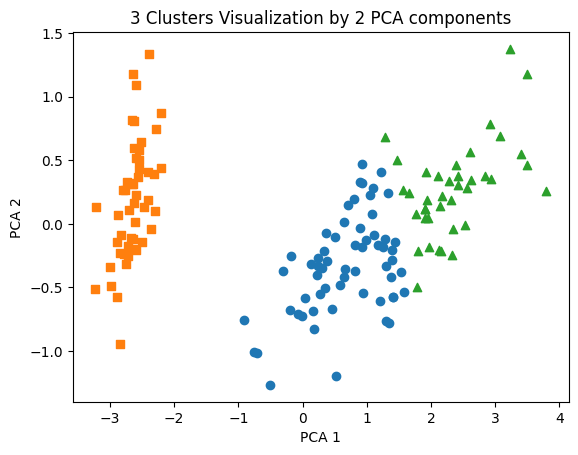

In [6]:
marker0_idx = irisDF[irisDF['cluster'] == 0].index
marker1_idx = irisDF[irisDF['cluster'] == 1].index
marker2_idx = irisDF[irisDF['cluster'] == 2].index

plt.scatter(irisDF.loc[marker0_idx, 'pca_x'], irisDF.loc[marker0_idx, 'pca_y'], marker = 'o')
plt.scatter(irisDF.loc[marker1_idx, 'pca_x'], irisDF.loc[marker1_idx, 'pca_y'], marker = 's')
plt.scatter(irisDF.loc[marker2_idx, 'pca_x'], irisDF.loc[marker2_idx, 'pca_y'], marker = '^')

plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('3 Clusters Visualization by 2 PCA components')
plt.show()

| 파라미터 | 설명 |
|-------|------------|
| n_samples | 디폴트 = 100 생성할 총 데이터의 개수 |
| n_features | 데이터의 피처 개수 |
| centers | int로 입력: 군집의 개수 ndarray로 입력: 개별 군집 중심점의 좌표 |
| cluster_std | 생성될 군집 데이터의 표준편차 <br> float로 입력: 군집 내 데이터의 표준 편차 <br>[float, …]로 입력: 각 군집의 순서대로 각각의 표준편차가 만들어짐. <br>⇒ 군집별로 서로 다른 표준편차를 가진 데이터 세트를 만들 때 사용 |


- `make_classification()`: 노이즈를 포함한 데이터를 만든다.
- `make_circle(), make_moon()`: 중심기반의 군집화로 해결하기 어려운 데이터 세트를 만듦

In [7]:
from sklearn.datasets import make_blobs

X, y = make_blobs(n_samples = 200, n_features = 2, centers = 3, cluster_std = 0.8, random_state = 0)
print(X.shape, y.shape)

unique, counts = np.unique(y, return_counts = True)
print(unique, counts)

(200, 2) (200,)
[0 1 2] [67 67 66]


In [8]:
clusterDF = pd.DataFrame(data = X, columns = ['ftr1', 'ftr2'])
clusterDF['target'] = y
clusterDF.head()

,ftr1,ftr2,target
0,-1.692427,3.622025,2
1,0.697940,4.428867,0
2,1.100228,4.606317,0
3,-1.448724,3.384245,2
4,1.214861,5.364896,0


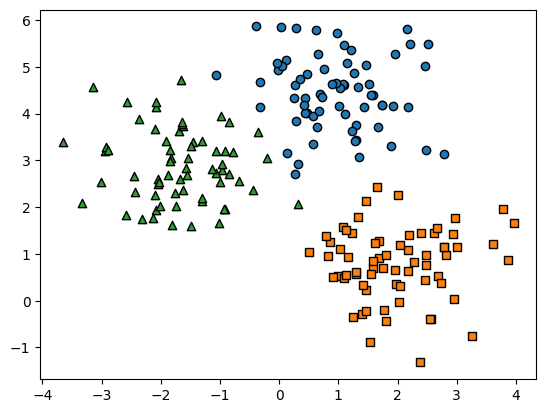

In [9]:
target_list = np.unique(y)

markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

for target in target_list:
  target_cluster = clusterDF[clusterDF['target'] == target]
  plt.scatter(x = target_cluster['ftr1'], y = target_cluster['ftr2'], edgecolor = 'k', marker = markers[target])

plt.show()

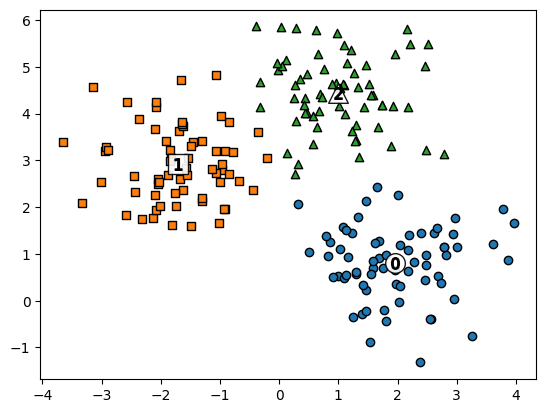

In [10]:
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 200, random_state = 0)
cluster_labels = kmeans.fit_predict(X)
clusterDF['kmeans_label'] = cluster_labels

centers = kmeans.cluster_centers_
unique_labels = np.unique(cluster_labels)
markers = ['o', 's', '^', 'P', 'D', 'H', 'x']

for label in unique_labels:
  label_cluster = clusterDF[clusterDF['kmeans_label'] == label]
  center_x_y = centers[label]
  plt.scatter(x = label_cluster['ftr1'], y = label_cluster['ftr2'], edgecolor = 'k', marker = markers[label])

  plt.scatter(x = center_x_y[0], y = center_x_y[1], s = 200, color = 'white', alpha = 0.9, edgecolor = 'k', marker = markers[label])
  plt.scatter(x = center_x_y[0], y = center_x_y[1], s = 70, color = 'k', edgecolor = 'k', marker = '$%d$' % label)

plt.show()

In [11]:
print(clusterDF.groupby('target')['kmeans_label'].value_counts())

target  kmeans_label
0       2               66
        1                1
1       0               67
2       1               65
        0                1
Name: count, dtype: int64


##Evaluation

**실루엣 분석**<br>
: 대부분의 군집화 데이터 세트는 타깃 레이블을 가지고 있지 않다.<br>
: 그래서 비지도 학습의 특성상 정확한 성능 평가는 어렵지만 군집화의 성능을 평가하는 방법으로는 실루엣 분석이 있다.

실루엣 분석: 각 군집 간의 거리가 얼마나 효율적으로 분리되어 있는지 나타냄
효율적 분리 <br>  ⇒ 다른 군집과는 떨어져 있고, 동일 군집끼리의 데이터는 서로 가깝게 잘 뭉쳐 있는것.<br>
군집화가 잘 될수록 개별 군집은 비슷한 정도의 여유공간을 가지고 떨어져 있다.<br><br>
**실루엣 계수(silhouette coefficient)** : 개별 데이터가 가지는 군집화 지표<br>
해당 데이터가 같은 군집 내의 데이터와 얼마나 가깝게 군집화 돼있고,<br>
다른 군집에 있는 데이터와는 얼마나 멀리 분리되어 있는지 나타내는 지표

In [12]:
from ast import increment_lineno
from sklearn.preprocessing import scale
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans

from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
%matplotlib inline

iris = load_iris()
feature_names = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']
irisDF = pd.DataFrame(data = iris.data, columns = feature_names)
kmeans = KMeans(n_clusters = 3, init = 'k-means++', max_iter = 300, random_state = 0).fit(irisDF)
irisDF['cluster'] = kmeans.labels_

score_samples = silhouette_samples(iris.data, irisDF['cluster'])
print('silhouette_samples( ) return 값의 shape', score_samples.shape)

irisDF['silhouette_coeff'] = score_samples

average_score = silhouette_score(iris.data, irisDF['cluster'])
print('붓꽃 데이터 세트 Silhouette Analysis Score: {0:.3f}'.format(average_score))
irisDF.head()

silhouette_samples( ) return 값의 shape (150,)
붓꽃 데이터 세트 Silhouette Analysis Score: 0.551


,sepal_length,sepal_width,petal_length,petal_width,cluster,silhouette_coeff
0,5.1,3.5,1.4,0.2,1,0.852582
1,4.9,3.0,1.4,0.2,1,0.814916
2,4.7,3.2,1.3,0.2,1,0.828797
3,4.6,3.1,1.5,0.2,1,0.804352
4,5.0,3.6,1.4,0.2,1,0.848918


In [13]:
irisDF.groupby('cluster')['silhouette_coeff'].mean()

,silhouette_coeff
cluster,
0,0.422323
1,0.797604
2,0.436842


In [14]:
import matplotlib.cm as cm
import math

def visualize_silhouette(cluster_lists, X_features):
  n_cols = len(cluster_lists)
  fig, axs = plt.subplots(figsize = (4*n_cols, 4), nrows = 1, ncols = n_cols)
  for idx, n_cluster in enumerate(cluster_lists):
    clusterer = KMeans(n_clusters = n_cluster, max_iter = 500, random_state = 0)
    cluster_labels = clusterer.fit_predict(X_features)

    sil_avg = silhouette_score(X_features, cluster_labels)
    sil_values = silhouette_samples(X_features, cluster_labels)

    y_lower = 10
    axs[idx].set_title('Number of Cluster: ' + str(n_cluster) + '\nSilhouette Score: ' + str(round(sil_avg, 3)))
    axs[idx].set_xlabel('The silhouette coefficient values')
    axs[idx].set_ylabel('Cluster label')
    axs[idx].set_xlim([-0.1, 1])
    axs[idx].set_ylim([0, len(X_features) + (n_cluster + 1) * 10])
    axs[idx].set_xticks([0, 0.2, 0.4, 0.6, 0.8, 1])
    axs[idx].set_yticks([])

    for i in range(n_cluster):
      ith_cluster_sil_values = sil_values[cluster_labels == i]
      ith_cluster_sil_values.sort()

      size_cluster_i = ith_cluster_sil_values.shape[0]
      y_upper = y_lower + size_cluster_i

      color = cm.nipy_spectral(float(i)/n_cluster)
      axs[idx].fill_betweenx(np.arange(y_lower, y_upper), 0, ith_cluster_sil_values, facecolor = color, edgecolor = color, alpha = 0.7)
      axs[idx].text(-0.05, y_lower + 0.5, str(i) + ' (' + str(size_cluster_i) + ')')
      y_lower = y_upper + 10

    axs[idx].axvline(x = sil_avg, color = 'red', linestyle = '--')

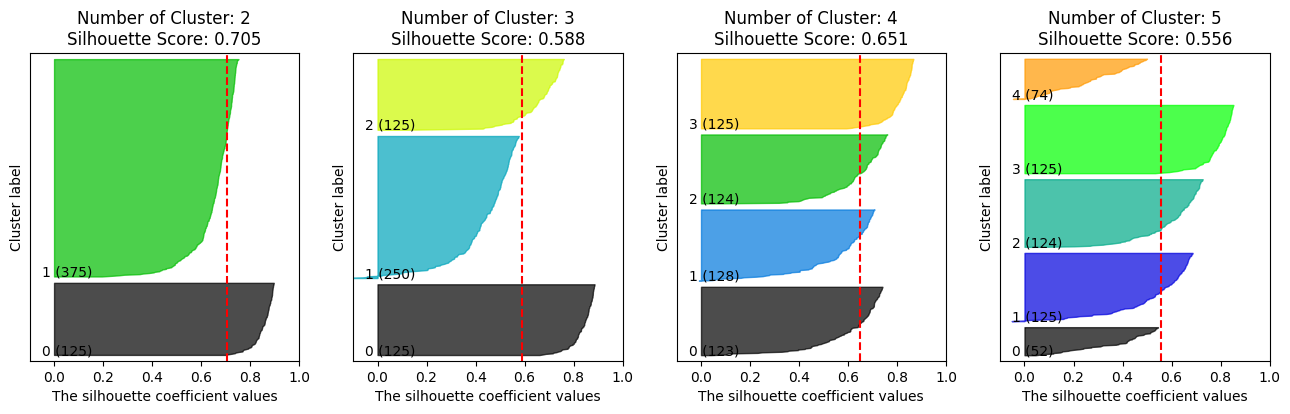

In [15]:
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples = 500, n_features = 2, centers = 4, cluster_std = 1, center_box = (-10.0, 10.0), shuffle = True, random_state = 1)

visualize_silhouette([2, 3, 4, 5], X)

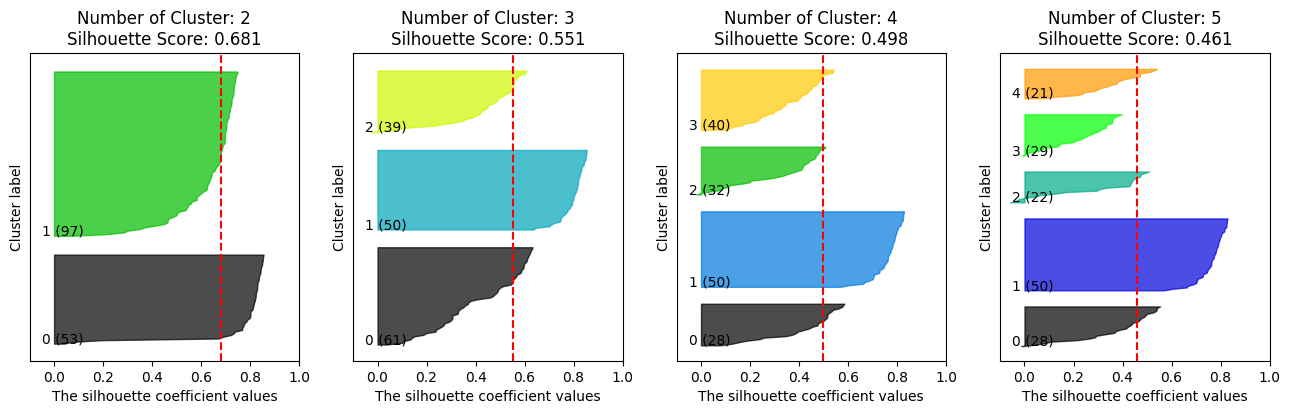

In [16]:
from sklearn.datasets import load_iris
iris = load_iris()
visualize_silhouette([2, 3, 4, 5], iris.data)